# 이동평균과 시계열 트렌드 분석

- `rolling()`으로 이동평균(moving average)을 계산해 데이터의 잔물결(noise)을 걷어내고 추세 분석
- 일별 누적 매출(`cumsum()`)을 함께 그려 "하루 단위 변동"과 "누적 추세"를 구분

In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

In [4]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)

C:\Users\soldesk\AppData\Local\Temp\ipykernel_4952\2504932276.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


In [9]:
daily_sales = df.groupby("ORDER_DATE")["PRICE"].sum().reset_index()
daily_sales.columns = ["ORDER_DATE", "일매출"]

daily_sales["3일이동평균"] = daily_sales["일매출"].rolling(window=3).mean()
daily_sales["누적매출"] = daily_sales["일매출"].cumsum()

daily_sales.head(10)

,ORDER_DATE,일매출,3일이동평균,누적매출
0,2026-08-01,9000,NaN,9000
1,2026-08-02,22000,NaN,31000
2,2026-08-03,25000,18666.666667,56000
3,2026-08-04,8000,18333.333333,64000
4,2026-08-05,13000,15333.333333,77000
5,2026-08-06,11000,10666.666667,88000
6,2026-08-07,18000,14000.000000,106000
7,2026-08-08,15500,14833.333333,121500
8,2026-08-09,67000,33500.000000,188500
9,2026-08-10,46000,42833.333333,234500


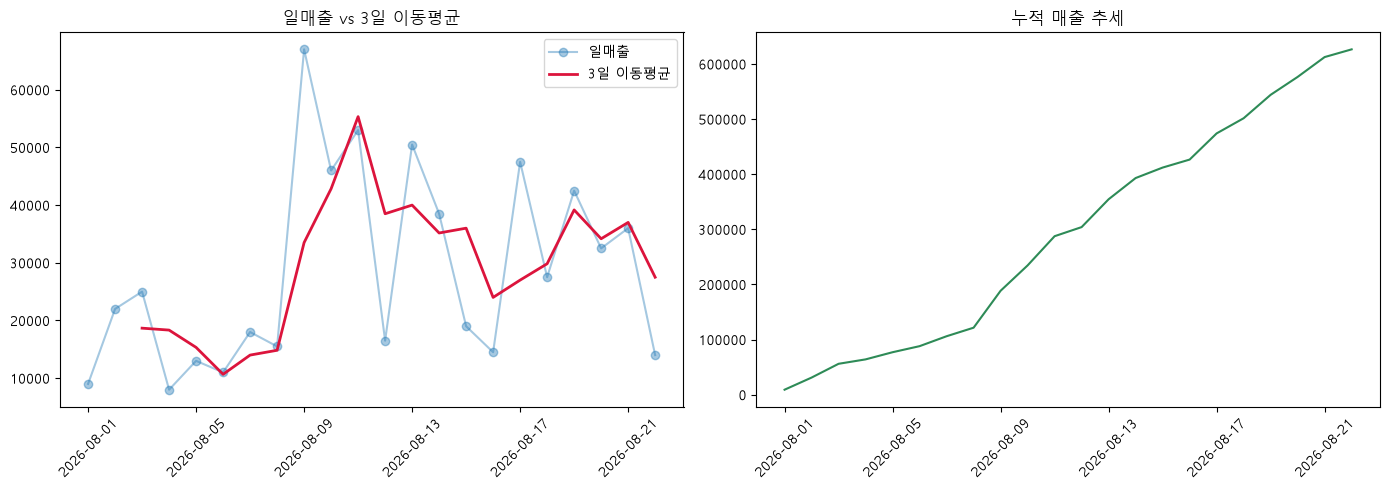

In [10]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["일매출"], label="일매출", alpha=0.4, marker="o")
axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["3일이동평균"], label="3일 이동평균", linewidth=2, color="crimson")
axes[0].set_title("일매출 vs 3일 이동평균")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(daily_sales["ORDER_DATE"], daily_sales["누적매출"], color="seagreen")
axes[1].set_title("누적 매출 추세")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()